# 05. Human-in-the-Loop (HITL) Approaches

## 📚 Learning Objectives

By completing this notebook, you will:
- Design human-in-the-loop (HITL) workflows
- Balance automation and human oversight
- Implement and evaluate HITL patterns

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 1, lesson 04 "Intelligent Agents and Rationality" — an autonomous agent acts on its own; this lesson is about where that autonomy should stop.

---


# 05. Human-in-the-Loop (HITL) Approaches

## 🚨 THE PROBLEM: We Need Human Oversight

**Remember the limitation from the previous notebook?**

We learned accountability frameworks for defining responsibilities. But we discovered:

**How do we incorporate human judgment into AI decision-making?**

**The Problem**: Ethical AI systems also need:
- ❌ **Human oversight** (human judgment for critical decisions)
- ❌ **Human-in-the-loop** (HITL) approaches
- ❌ **Human review** for uncertain cases
- ❌ **Human validation** of AI decisions

**We've learned:**
- ✅ How to use SHAP, LIME, and counterfactuals (Notebooks 1-3)
- ✅ How to establish accountability frameworks (Notebook 4)
- ✅ Explanation methods and accountability

**But we haven't learned:**
- ❌ How to **incorporate human judgment** into AI decisions
- ❌ How to implement **human-in-the-loop** approaches
- ❌ How to enable **human review** for uncertain cases
- ❌ How to **combine AI with human judgment**

**We need human-in-the-loop approaches** to:
1. Incorporate human judgment into AI decisions
2. Enable human review for uncertain cases
3. Provide human oversight for critical decisions
4. Combine AI efficiency with human judgment

**This notebook solves that problem** by teaching you human-in-the-loop approaches for ethical AI!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: SHAP Explanations** - Understanding explainability
- ✅ **Example 2: LIME Explanations** - Understanding local explanations
- ✅ **Example 3: Counterfactual Analysis** - Understanding "what if" scenarios
- ✅ **Example 4: Accountability Frameworks** - Understanding accountability
- ✅ **Basic Python knowledge**: Functions, data manipulation

**If you haven't completed these**, you might struggle with:
- Understanding why human oversight matters
- Knowing how to implement HITL approaches
- Understanding human-AI collaboration

---

## 🔗 Where This Notebook Fits

**This is the FIFTH example in Unit 4** - it teaches you human oversight!

**Why this example FIFTH?**
- **Before** you can implement HITL, you need explainability (Examples 1-3)
- **Before** you can implement HITL, you need accountability (Example 4)
- **Before** you can build transparent systems, you need human oversight

**Builds on**: 
- 📓 Example 1: SHAP Explanations (explainability)
- 📓 Example 2: LIME Explanations (local explanations)
- 📓 Example 3: Counterfactual Analysis ("what if" scenarios)
- 📓 Example 4: Accountability Frameworks (accountability)

**Leads to**: 
- 📓 Example 6: Transparency Tools (transparency frameworks)

**Why this order?**
1. HITL provides **human oversight** (needed for ethical AI)
2. HITL teaches **human-AI collaboration** (critical for trust)
3. HITL shows **uncertainty handling** (essential for transparency)

---

## The Story: Combining AI with Human Judgment

Imagine you're a doctor using AI to diagnose patients. **Before** HITL, AI would make all decisions automatically (risky!). **After** implementing HITL, uncertain cases get human review - combining AI efficiency with human judgment!

Same with AI: **Before** we have automated decisions but no human oversight, now we learn HITL - incorporate human judgment for uncertain cases! **After** HITL, we have AI systems with human oversight!

---

## Why HITL Approaches Matter

Human-in-the-loop approaches are essential for ethical AI:
- **Human Judgment**: Incorporate human expertise into AI decisions
- **Oversight**: Provide human oversight for critical decisions
- **Trust**: Build user confidence through human involvement
- **Safety**: Reduce risks through human validation
- **Ethics**: Ensure ethical decisions through human judgment

## Learning Objectives
1. Understand human-in-the-loop approaches
2. Learn how to identify uncertain cases
3. Implement human review mechanisms
4. Combine AI predictions with human judgment
5. Evaluate HITL effectiveness
6. Design HITL workflows

## 📌 The case: the humans were in the loop, and it made it worse

**The British Post Office Horizon scandal.** Between **1999 and 2015**, more than **900
subpostmasters** were prosecuted for theft and false accounting on the strength of shortfalls
reported by **Horizon**, a Fujitsu accounting system. Around 236 went to prison. Others
remortgaged homes to repay money that had never gone missing.

There were humans in that loop at every step: auditors, investigators, Post Office lawyers,
magistrates, juries. Every one of them treated the computer's figure as the fact and the
person's account as the doubt. In **Bates v Post Office (2019)** the High Court found that
Horizon "contained bugs, errors and defects"; in **April 2021** the Court of Appeal quashed
39 convictions, holding that a fair trial had not been possible.

**Australia's Robodebt** is the same shape with different software: automated income
averaging raised roughly **470,000 wrongly issued debts**, on **11 June 2021** the Federal
Court of Australia approved a settlement reported at **at least A$1.8 billion**, and the
Royal Commission's report of **7 July 2023** called it "a costly failure of public
administration, in both human and economic terms".

Human oversight was present in both, and it did not work — because a human who defers to the
machine is not oversight, they are a rubber stamp with a signature. The EU legislature
eventually wrote the failure mode into law: **AI Act Article 14(4)(b)** requires that people
overseeing a high-risk system "remain aware of the possible tendency of automatically relying
or over-relying on the output produced by a high-risk AI system (**automation bias**)", and
**Article 14(4)(d)** requires that they be able to **disregard, override or reverse** the
output.

**The WHY — what goes wrong without designed HITL.** "A human reviews it" is the most common
answer to every AI risk question and the least examined. Unless you decide **which** cases go
to a human, **what** the human sees, and **whether** their decisions actually differ from the
model's, you have added a person to the process and no safety at all. You are about to price
that design: how much staffing buys how much reliability.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../../Course 04/datasets/raw/titanic.csv` - 891 real passengers. Six real,
  interpretable features (`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `is_female`)
  and the real recorded outcome, `Survived`.
- This is deliberately the same model Unit 2 audited for fairness, so the
  explanations here can be checked against those findings.

**Outputs:** What you'll see when you run the cells

- A confidence-threshold sweep on the real survival model
- Measured accuracy of the automated decisions vs the deferred ones
- **Who gets deferred**: the deferral rate per group, because a routing rule
  is itself a decision with disparate impact

---

## Part 1: Confidence-Based Routing - HITL You Can Run

The core HITL mechanism: the model handles cases it is confident about, and **defers the
uncertain ones to a human**. We implement it with a probability threshold and measure what
it buys us. (Unit 2's fair-development notebook previewed this idea; here we build the
routing itself and study the threshold trade-off.)

Real passengers: 891 (train 623 / test 268)
Fully-automated accuracy (no HITL): 0.802

HITL ROUTING AT DIFFERENT CONFIDENCE THRESHOLDS
 threshold  automated_share  auto_accuracy  deferred_share  deferred_model_accuracy
       0.6            0.899          0.826           0.101                    0.593
       0.7            0.772          0.850           0.228                    0.639
       0.8            0.653          0.880           0.347                    0.656
       0.9            0.474          0.913           0.526                    0.702

Pattern: raising the threshold sends MORE cases to humans, and the
automated remainder gets MORE reliable - staffing cost vs error cost.

Best automated-decision accuracy in this sweep: 0.913, +0.111 against the no-HITL baseline of 0.802.
That gain is bought by handing 52.6% of the caseload to people.

WHO GETS DEFERRED? Auditing the routing rule as a decision
At threshold 0.7:
Group          n    Deferred to humans    Auto-decision accurac

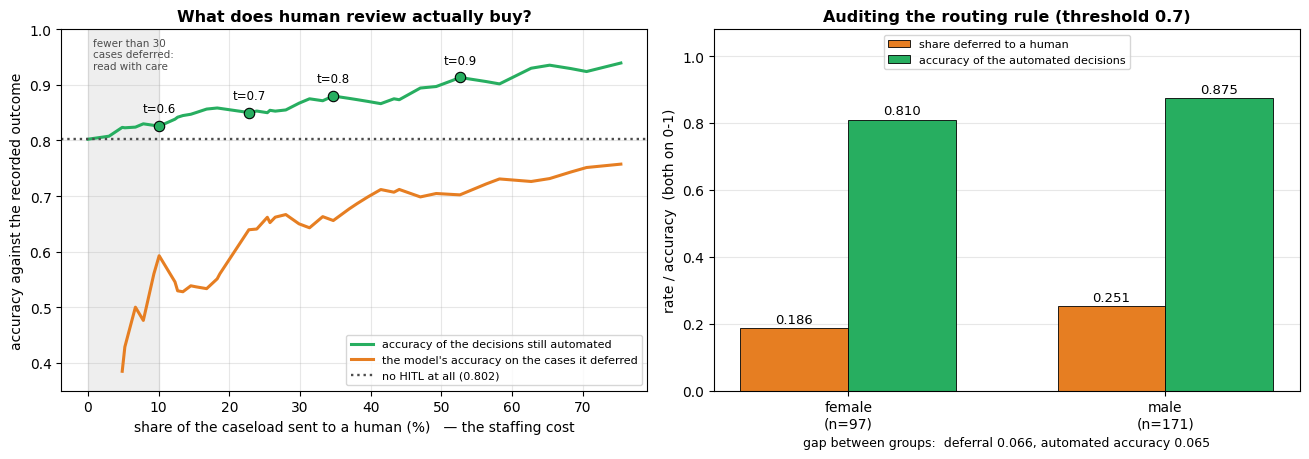


Design checklist for real HITL systems (what we just demonstrated + policy):
  1. Defer on LOW CONFIDENCE (implemented above)
  2. Defer on HIGH STAKES regardless of confidence (policy rule)
  3. AUDIT the routing rule per group (implemented above)
  4. Log reviewer + outcome in the audit trail (Notebook 04)
  5. Feed human corrections back into training data


In [1]:
# Why HITL: no model is reliable everywhere - routing low-confidence cases to
# humans buys accuracy where the model is weakest, at a staffing cost we can measure.

# Step 2: Implement confidence-based human-in-the-loop routing on real data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Same real setup as Notebooks 01-03: the real Titanic manifest.
df = pd.read_csv('../../../Course 04/datasets/raw/titanic.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
X = pd.DataFrame({
    'Pclass':    df['Pclass'].astype(float),
    'Age':       df['Age'].astype(float),
    'SibSp':     df['SibSp'].astype(float),
    'Parch':     df['Parch'].astype(float),
    'Fare':      df['Fare'].astype(float),
    'is_female': (df['Sex'] == 'female').astype(float),
})
y = df['Survived'].values
# Keep the group label alongside the split so we can audit WHO gets deferred.
group = df['Sex'].values
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, group, test_size=0.3, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
print(f"Real passengers: {len(df)} (train {len(X_train)} / test {len(X_test)})")

# Confidence = the probability of the winning class; it is the routing signal.
proba = model.predict_proba(X_test)
confidence = proba.max(axis=1)
pred = model.predict(X_test)
overall = accuracy_score(y_test, pred)
print(f"Fully-automated accuracy (no HITL): {overall:.3f}")

def hitl_route(threshold):
    """Split decisions into automated vs human-review at a confidence threshold."""
    auto = confidence >= threshold
    return {
        'threshold': threshold,
        'automated_share': auto.mean(),
        'auto_accuracy': accuracy_score(y_test[auto], pred[auto]) if auto.any() else np.nan,
        'deferred_share': (~auto).mean(),
        'deferred_model_accuracy': (accuracy_score(y_test[~auto], pred[~auto])
                                    if (~auto).any() else np.nan),
    }

print("\nHITL ROUTING AT DIFFERENT CONFIDENCE THRESHOLDS")
print("=" * 80)
# Sweep four thresholds and tabulate the trade-off at each one.
rows = [hitl_route(t) for t in [0.6, 0.7, 0.8, 0.9]]
table = pd.DataFrame(rows)
print(table.round(3).to_string(index=False))
print("\nPattern: raising the threshold sends MORE cases to humans, and the")
print("automated remainder gets MORE reliable - staffing cost vs error cost.")

gain = table['auto_accuracy'].max() - overall
print(f"\nBest automated-decision accuracy in this sweep: "
      f"{table['auto_accuracy'].max():.3f}, "
      f"{gain:+.3f} against the no-HITL baseline of {overall:.3f}.")
print("That gain is bought by handing "
      f"{table.loc[table['auto_accuracy'].idxmax(), 'deferred_share']:.1%} "
      "of the caseload to people.")

# --- Audit the routing rule itself ---
# WHY: HITL is usually presented as a safety net. It is also an allocation of a
# scarce resource (human attention), so it needs the same fairness scrutiny as
# the model - exactly the Unit 2 method applied to a workflow decision.
print("\n" + "="*80)
print("WHO GETS DEFERRED? Auditing the routing rule as a decision")
print("="*80)
THRESHOLD = 0.7
auto_mask = confidence >= THRESHOLD
defer_stats = {}
for g in sorted(set(g_test)):
    mask = (g_test == g)
    deferred = (~auto_mask)[mask]
    auto_here = auto_mask[mask]
    defer_stats[g] = {
        'n': int(mask.sum()),
        'defer_rate': deferred.mean(),
        'auto_acc': (accuracy_score(y_test[mask & auto_mask], pred[mask & auto_mask])
                     if (mask & auto_mask).any() else np.nan),
    }
print(f"At threshold {THRESHOLD}:")
print(f"{'Group':<10}{'n':>6}{'Deferred to humans':>22}{'Auto-decision accuracy':>26}")
for g, s in defer_stats.items():
    print(f"{g:<10}{s['n']:>6}{s['defer_rate']:>21.1%}{s['auto_acc']:>26.3f}")

rates = [s['defer_rate'] for s in defer_stats.values()]
accs = [s['auto_acc'] for s in defer_stats.values()]
print(f"\n  Deferral-rate gap between groups   : {max(rates) - min(rates):.3f}")
print(f"  Automated-accuracy gap between groups: {max(accs) - min(accs):.3f}")
print("\n  Two different harms hide in those two numbers:")
print("  - a higher deferral rate means longer waits and more dependence on")
print("    whoever reviews the case;")
print("  - a lower automated accuracy means the decisions that were NOT reviewed")
print("    are less reliable for that group - the safety net had a hole in it")
print("    exactly where it was needed.")
print("  Audit both. A HITL policy is not automatically the fair option.")

# WHY replot this as a cost curve: the manager's question is not "what
# threshold?" but "how much of my caseload am I willing to send to people, and
# what does that buy?" So we put the staffing cost on the x-axis and sweep it
# finely, marking the four thresholds from the table so it can still be read as
# a threshold. np.round keeps the sweep values off floating-point edges.
sweep = pd.DataFrame([hitl_route(t)
                      for t in np.round(np.linspace(0.50, 0.97, 48), 4)])

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7))

ax = axes[0]
ax.plot(sweep['deferred_share'] * 100, sweep['auto_accuracy'], '-',
        color='#27ae60', lw=2.2,
        label='accuracy of the decisions still automated')
# Below ten deferred cases the statistic is meaningless, so we do not draw it
# rather than drawing a line the student cannot read honestly.
n_deferred = sweep['deferred_share'] * len(y_test)
ax.plot(sweep['deferred_share'] * 100,
        sweep['deferred_model_accuracy'].where(n_deferred >= 10), '-',
        color='#e67e22', lw=2.2,
        label="the model's accuracy on the cases it deferred")
ax.axhline(overall, color='0.30', ls=':', lw=1.7,
           label=f'no HITL at all ({overall:.3f})')
for _, r in table.iterrows():
    ax.plot(r['deferred_share'] * 100, r['auto_accuracy'], 'o', color='#27ae60',
            ms=7.5, mec='black', mew=0.8, zorder=5)
    ax.annotate(f"t={r['threshold']:.1f}",
                (r['deferred_share'] * 100, r['auto_accuracy']),
                textcoords='offset points', xytext=(0, 10), ha='center',
                fontsize=8.5)
# Left of this band the deferred pile is only a few dozen cases, so its accuracy
# jumps around. Say so on the figure rather than letting a student over-read it.
small = sweep['deferred_share'] * len(y_test) < 30
if small.any():
    ax.axvspan(0, sweep.loc[small, 'deferred_share'].max() * 100,
               color='0.55', alpha=0.14, zorder=0)
    ax.text(0.7, 0.985, 'fewer than 30\ncases deferred:\nread with care',
            fontsize=7.5, color='0.30', va='top', ha='left')
ax.set_xlabel('share of the caseload sent to a human (%)   — the staffing cost')
ax.set_ylabel('accuracy against the recorded outcome')
ax.set_ylim(0.35, 1.0)
ax.set_title('What does human review actually buy?',
             fontsize=11.5, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

# --- Right: the routing rule audited as a decision in its own right ---
ax = axes[1]
groups = list(defer_stats.keys())
xg = np.arange(len(groups))
w = 0.34
b1 = ax.bar(xg - w / 2, [defer_stats[g]['defer_rate'] for g in groups], w,
            label='share deferred to a human', color='#e67e22',
            edgecolor='black', linewidth=0.6)
b2 = ax.bar(xg + w / 2, [defer_stats[g]['auto_acc'] for g in groups], w,
            label='accuracy of the automated decisions', color='#27ae60',
            edgecolor='black', linewidth=0.6)
for bar_set in (b1, b2):
    for bar in bar_set:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.016,
                f"{bar.get_height():.3f}", ha='center', fontsize=9.5)
ax.set_xticks(xg)
ax.set_xticklabels([f"{g}\n(n={defer_stats[g]['n']})" for g in groups])
ax.set_ylim(0, 1.08)
ax.set_ylabel('rate / accuracy  (both on 0-1)')
ax.set_xlabel(f"gap between groups:  deferral {max(rates) - min(rates):.3f}, "
              f"automated accuracy {max(accs) - min(accs):.3f}", fontsize=9)
ax.set_title(f'Auditing the routing rule (threshold {THRESHOLD})',
             fontsize=11.5, fontweight='bold')
ax.legend(fontsize=8, loc='upper center')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("\nDesign checklist for real HITL systems (what we just demonstrated + policy):")
print("  1. Defer on LOW CONFIDENCE (implemented above)")
print("  2. Defer on HIGH STAKES regardless of confidence (policy rule)")
print("  3. AUDIT the routing rule per group (implemented above)")
print("  4. Log reviewer + outcome in the audit trail (Notebook 04)")
print("  5. Feed human corrections back into training data")

**Read the figure.**

*Left — what human review buys.* The x-axis is the thing you have to pay for: the percentage
of the 268 held-out cases handed to a person. The green line is the accuracy of what is left
running automatically, and it climbs from the dotted **0.802** no-HITL baseline to about
**0.91** — but only by the time you are deferring more than half the caseload (the marked
points are the four thresholds from the table; `t=0.9` sits at 52.6%). The orange line is the
model's own accuracy on the pile it *deferred*, and this is the line most HITL designs never
plot: it **rises too**. Early deferrals are cases the model really would have got wrong
(≈0.59); by the time you are deferring half the work, the marginal deferred case is one the
model would have got right about **70%** of the time. Every extra reviewer you hire is
therefore worth less than the one before. The grey strip on the left warns that under 30 deferred
cases the orange line is computed on too few cases to trust — inside it the line dips to
**0.385** on thirteen cases, which is noise, not a finding, and below ten deferred cases it is
not drawn at all.

*Right — the routing rule is itself a decision.* At threshold 0.7 the two orange bars are not
equal: **18.6%** of women are deferred against **25.1%** of men, a gap of **0.066**. The green
bars are not equal either: the decisions left automated are right **81.0%** of the time for
women and **87.5%** for men, a gap of **0.065** in the other direction. So the group deferred
*less* often is also the group whose unreviewed decisions are *less* reliable — the safety net
is thinnest where the model is weakest.

**What this does not show.** Nothing here measures the reviewers. Both lines are accuracies of
*the model*; the claim "a human would do better on the deferred pile" is assumed, not
measured, and Horizon and Robodebt are what that assumption costs.

## 💬 Discuss

Your own sweep on 268 real held-out passengers:

| Threshold | Automated share | Automated accuracy | Deferred share | Model accuracy on deferred |
|---|---|---|---|---|
| none (no HITL) | 1.000 | **0.802** | 0.000 | — |
| 0.6 | 0.899 | 0.826 | 0.101 | 0.593 |
| 0.7 | 0.772 | 0.850 | 0.228 | 0.639 |
| 0.8 | 0.653 | 0.880 | 0.347 | 0.656 |
| 0.9 | 0.474 | **0.913** | **0.526** | 0.702 |

1. **Buy a threshold.** Going to 0.9 raises automated accuracy by **11.1 points** and sends
   **52.6 %** of cases to a human — roughly half your volume, i.e. roughly half a
   department. Pick the threshold you would fund, and defend it as a budget line: how many
   reviewers, at what cost per case, for how many prevented errors? Then say what changes if
   this is a medical triage system rather than a benefits screen.
2. **Where is the evidence the humans are better?** Every number above measures the *model's*
   accuracy on the deferred cases (0.593 at threshold 0.6 — the model is genuinely bad on
   what it defers). Nothing here measures the **reviewers**. Horizon and Robodebt are what
   happens when nobody checks. Design the measurement: how would you find out whether your
   reviewers beat the model on the deferred set, without creating an experiment that harms
   the people in it?
3. **Audit the routing rule, because it is a decision.** The right-hand panel shows the
   deferral rate is **not group-neutral**. Whoever is deferred waits longer and depends on
   reviewer quality. Is a routing rule that defers one group more often unfair — or is it
   *correct*, since the model is genuinely less certain about that group? Argue both, then
   say what you would tell the deferred applicant about why their case takes three weeks
   longer.


---

## 🚫 When HITL Approaches Hit a Limitation

### The Limitation We Discovered

We've learned human-in-the-loop approaches for incorporating human judgment. **But there's still a challenge:**

**How do we integrate all transparency tools into a comprehensive framework?**

HITL approaches work well when:
- ✅ We can identify uncertain cases
- ✅ We can incorporate human judgment
- ✅ We have human oversight mechanisms

**But comprehensive transparency also needs:**
- ❌ **Integrated transparency tools** (combine all explanation methods)
- ❌ **Transparency frameworks** (systematic approach to transparency)
- ❌ **Tool comparison** (choose the right tool for each situation)
- ❌ **Complete transparency solutions** (end-to-end transparency)

### Why This Is a Problem

When we have individual tools but no framework:
- We may not know which tool to use when
- We may not integrate tools effectively
- We may not have a systematic transparency approach
- We may miss important transparency aspects

### The Solution: Transparency Tools and Frameworks

We need **transparency tools and frameworks** to:
1. Compare and integrate different explanation methods
2. Create comprehensive transparency frameworks
3. Choose the right tool for each situation
4. Build complete transparency solutions

**This is exactly what we'll learn in the next notebook: Transparency Tools!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use SHAP, LIME, and counterfactuals (Notebooks 1-3)
- ✅ How to establish accountability (Notebook 4)
- ✅ How to implement HITL (This notebook!)
- ✅ **The limitation**: We need comprehensive transparency frameworks!

**Next notebook**: `06_transparency_tools.ipynb`
- Learn about transparency tools comparison
- Understand transparency frameworks
- Integrate all explanation methods
- Build comprehensive transparency solutions

## ⚠️ Where this breaks

- **Automation bias is the default, not the exception.** People shown a machine's answer
  agree with it, especially under time pressure and especially when it is usually right. That
  is why AI Act Art. 14(4)(b) names it explicitly. A reviewer who sees the model's
  probability before forming a view is anchored; if you want independent judgement, **hide
  the score until after they have decided**, then reconcile.
- **Confidence is not correctness.** This whole routing rule assumes predicted probability
  tracks reliability. A poorly calibrated model is confidently wrong, and those cases are
  precisely the ones that never reach a human. Check calibration before you trust a threshold,
  and note that Unit 2's mitigation techniques can *change* calibration as a side effect.
- **Deferral is a cost paid by the applicant, not only by you.** Half your volume queued means
  someone waits. In a benefits or asylum context, delay is itself a harm — so "defer more" is
  not automatically the safe choice.
- **Reviewer capacity is finite and reviewers degrade.** A queue of 52 % at constant staffing
  produces rushed reviews, which produces exactly the rubber-stamping this design was meant
  to prevent. HITL that is not staffed is worse than no HITL, because it manufactures a
  signature.
- **Nobody in this notebook measured the humans.** Every accuracy figure above is the model's.
  A real HITL system needs reviewer agreement rates, reviewer-versus-model accuracy on the
  deferred set, and per-reviewer drift — logged in the audit trail from Notebook 04.
- **A human can be a liability shield rather than a safeguard.** The Post Office had
  investigators, lawyers and courts. Under the SCHUFA reasoning (Notebook 01), a human who
  simply follows the score does not turn an automated decision into a human one — legally or
  ethically.

**The cheaper alternative:** if you cannot staff review properly, **do not automate the
high-stakes slice at all**. A system that handles the easy 47 % and refuses the rest, openly,
is more honest than one that routes 52 % to a queue nobody can serve — and far more honest
than one that automates everything and calls the appeals process "human oversight".


## 📚 References

1. Amershi, S., Cakmak, M., Knox, W. B. & Kulesza, T. (2014). *Power to the People: The Role of Humans in Interactive Machine Learning*. AI Magazine, 35(4). <https://ojs.aaai.org/aimagazine/index.php/aimagazine/article/view/2513>
2. Wu, X., Xiao, L., Sun, Y., Zhang, J., Ma, T. & He, L. (2022). *A Survey of Human-in-the-loop for Machine Learning*. Future Generation Computer Systems, 135. <https://arxiv.org/abs/2108.00941>
3. European Parliament & Council (2024). *Regulation (EU) 2024/1689 — the EU AI Act* (Art. 14: human oversight). <https://digital-strategy.ec.europa.eu/en/policies/regulatory-framework-ai>